In [23]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load IMDB dataset

max_features = 10000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [24]:
x_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [25]:
y_train

array([1, 0, 0, ..., 0, 1, 0])

In [26]:
max_len = 200

x_train = keras.preprocessing.sequence.pad_sequences( x_train, maxlen=max_len)

x_test = keras.preprocessing.sequence.pad_sequences( x_test, maxlen=max_len)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


#LSTM model

In [27]:
model = keras.Sequential([
    layers.Embedding( input_dim=max_features, output_dim=128 ),
    layers.LSTM(64),
    layers.Dense( 1, activation="sigmoid" )
])


32 -batch size, maxlen=200,embedding size=128

      (32, 200, 128)
       ↓

       LSTM(64)

       ↓

       (32, 64)
        ↓

       (32, 1)




In [28]:
model.compile( optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


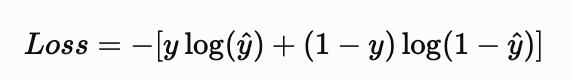

In [29]:

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit( x_train,y_train,epochs=2,batch_size=64, validation_split=0.2)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 261ms/step - accuracy: 0.7959 - loss: 0.4407 - val_accuracy: 0.8676 - val_loss: 0.3198
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.9033 - loss: 0.2486 - val_accuracy: 0.8790 - val_loss: 0.2941


25,000×0.8=20,000

Number of steps = 20,000/64
	​

=312.5

Since you cannot have half a batch, Keras is using 313 batches.

In [31]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

In [32]:
test_loss, test_accuracy = model.evaluate(x_test,y_test)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8712 - loss: 0.3113

Test Loss: 0.3113
Test Accuracy: 0.8712
